# Joint ATAC-RNA factorization with partially paired cells

We fit two observation models and learn
`p(L_ATAC, L_RNA) = p(L_ATAC) p(L_RNA | L_ATAC)`.
Each modality has its own factors and ordinary ash feature priors.
**The interface is two cEBMF objects and one `fit_joint` call.**
Passing `atac.L` as fixed `X_l` to an independent RNA fit would lose ATAC
uncertainty and RNA-to-ATAC posterior feedback.

This is a small Gaussian toy, not a raw-count analysis or a benchmark of
superiority. Run all cells in order. The script also accepts `--quick`.


In [1]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from cebmf_torch import align_modalities, cEBMF, fit_joint

torch.set_num_threads(1)
torch.manual_seed(8)
quick = "--quick" in sys.argv
n_cells = 80 if quick else 120
noise_sd = 0.7
iterations = 5 if quick else 8


## 1. Make two related measurements
Two binary ATAC programs give four possible regulatory states. Each state
activates one RNA program: a nonlinear conditional relationship.
True loadings are used only for simulation and evaluation.


In [2]:
true_atac_loadings = torch.bernoulli(torch.full((n_cells, 2), 0.5))
cell_state = (2 * true_atac_loadings[:, 0] + true_atac_loadings[:, 1]).long()
true_rna_loadings = torch.nn.functional.one_hot(cell_state, 4).float()
true_atac_factors = torch.zeros(60, 2)
true_atac_factors[5:25, 0] = 1
true_atac_factors[35:55, 1] = 1
true_rna_factors = torch.zeros(80, 4)
for k in range(4):
    true_rna_factors[20 * k:20 * (k + 1), k] = 1
atac_signal = true_atac_loadings @ true_atac_factors.T
rna_signal = true_rna_loadings @ true_rna_factors.T
atac_measurements = atac_signal + noise_sd * torch.randn_like(atac_signal)
rna_measurements = rna_signal + noise_sd * torch.randn_like(rna_signal)


## 2. Keep paired cells and cells measured in only one modality
Cell IDs determine the alignment. The inputs need not have the same row
count or order. `align_modalities` constructs their union and marks absent
measurements with NaN. Missing rows are never zero-valued observations.
Held-out measurements remain available only for evaluation.


In [3]:
order = torch.randperm(n_cells)
unpaired_per_modality = n_cells // 6
atac_ids = order[:-unpaired_per_modality]
rna_ids = order[unpaired_per_modality:]
data = align_modalities(atac_measurements[atac_ids], rna_measurements[rna_ids],
                        atac_ids=atac_ids, rna_ids=rna_ids)
paired = data.atac_observed & data.rna_observed
atac_only = data.atac_observed & ~data.rna_observed
rna_only = data.rna_observed & ~data.atac_observed
print(f"{int(paired.sum())} paired, {int(atac_only.sum())} ATAC-only, {int(rna_only.sum())} RNA-only cells")


80 paired, 20 ATAC-only, 20 RNA-only cells


## 3. Construct two cEBMF models and fit them jointly
`self_row_cov=True` learns dependence on earlier loadings within each model.
`fit_joint(atac, rna)` additionally connects ATAC loadings to RNA priors.
Argument order specifies the generative direction; posterior information
can flow both ways. `prior_F="norm"` is ash and is refitted during learning.

Small networks and neutral penalties keep the demonstration manageable.
Rank stays fixed while fitting a conditional graph. Quadrature and fixed
parent-integration points approximate expectations; there is no MCMC chain.


In [4]:
settings = dict(
    prior_L="cgb", prior_F="norm", self_row_cov=True, S=noise_sd, device="cpu",
    prior_L_kwargs={"hidden_dim": 12, "n_layers": 1, "n_epochs": 3 if quick else 5,
                    "lr": 0.01, "penalty": 1},
    prior_F_kwargs={"penalty": 1},
    conditional_kwargs={"quadrature_points": 12 if quick else 16, "parent_samples": 16},
)
atac = cEBMF(data.atac, K=2, **settings)
rna = cEBMF(data.rna, K=4, **settings)

started = time.perf_counter()
atac_fit, rna_fit = fit_joint(atac, rna, maxit=iterations)
elapsed = time.perf_counter() - started
print(f"Joint fit finished in {elapsed:.1f} seconds ({iterations} variational sweeps).")


Joint fit finished in 22.4 seconds (8 variational sweeps).


## 4. Evaluate each group separately
Paired cells assess denoising. RNA predictions for ATAC-only cells and ATAC
predictions for RNA-only cells assess an entirely unobserved modality.
The score uses noiseless simulation truth; lower RMSE is better. It is not
directly comparable to an RMSE against noisy measurements.


ATAC  | paired    | signal RMSE 0.141
ATAC  | ATAC only | signal RMSE 0.141
ATAC  | RNA only  | signal RMSE 0.333
RNA   | paired    | signal RMSE 0.161
RNA   | ATAC only | signal RMSE 0.374
RNA   | RNA only  | signal RMSE 0.176


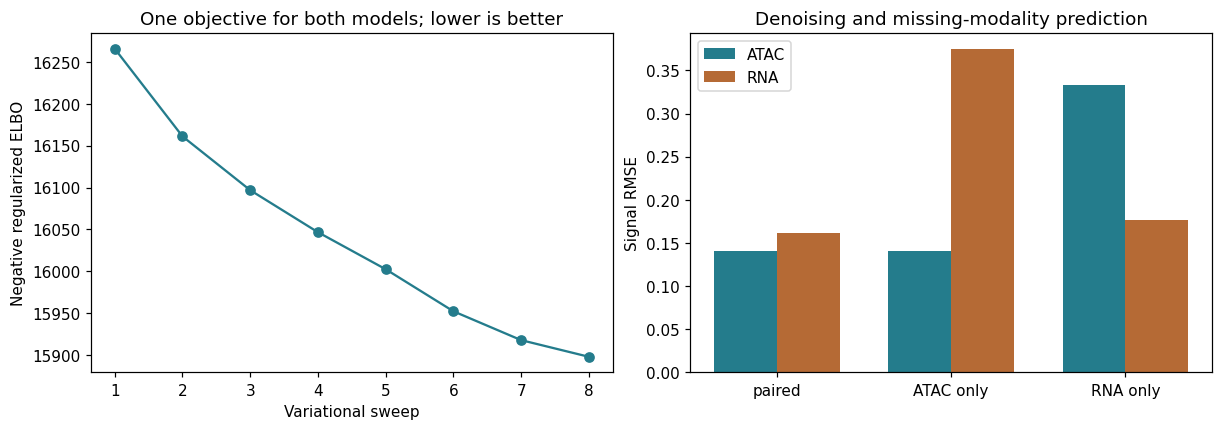

In [5]:
union_ids = torch.tensor(data.ids)
truth = {"ATAC": atac_signal[union_ids], "RNA": rna_signal[union_ids]}
fits = {"ATAC": atac_fit, "RNA": rna_fit}
groups = {"paired": paired, "ATAC only": atac_only, "RNA only": rna_only}
scores = []
for modality, result in fits.items():
    for group, rows in groups.items():
        rmse = (result.reconstruction[rows] - truth[modality][rows]).square().mean().sqrt().item()
        scores.append({"modality": modality, "cells": group, "signal_rmse": rmse})
        print(f"{modality:5s} | {group:9s} | signal RMSE {rmse:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
objective_history = torch.stack(atac_fit.history_obj).cpu().tolist()  # reporting boundary
axes[0].plot(range(1, iterations + 1), objective_history, marker="o", color="#247c8c")
axes[0].set(xlabel="Variational sweep", ylabel="Negative regularized ELBO",
            title="One objective for both models; lower is better")
for offset, modality, color in [(-0.18, "ATAC", "#247c8c"), (0.18, "RNA", "#b56a35")]:
    values = [row["signal_rmse"] for row in scores if row["modality"] == modality]
    axes[1].bar(torch.arange(3) + offset, values, width=0.36, label=modality, color=color)
axes[1].set(xticks=[0, 1, 2], xticklabels=list(groups), ylabel="Signal RMSE",
            title="Denoising and missing-modality prediction")
axes[1].legend()
plt.show()


## 5. Inspect predictions where a whole modality was missing
Cells are sorted by their simulated state only for this display. Fitting
never saw these labels. These are posterior-mean predictions, not observed
measurements or demonstrations that the latent programs were recovered.


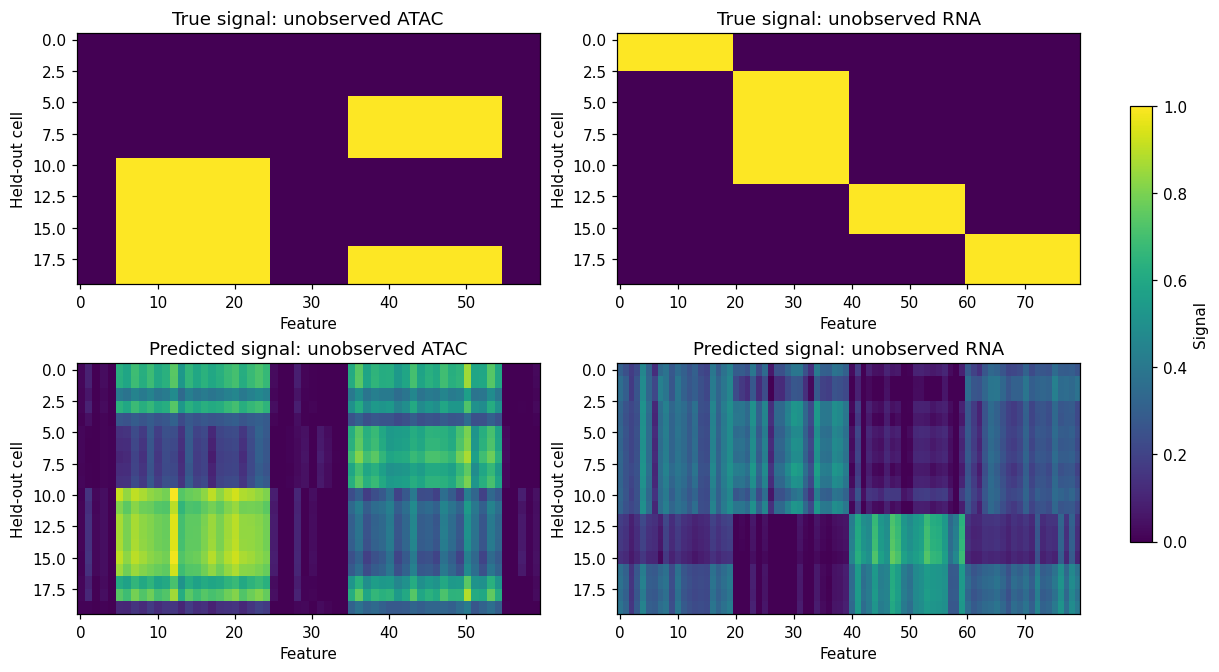

In [6]:
fig_missing, axes = plt.subplots(2, 2, figsize=(11, 6), constrained_layout=True)
for column, (modality, rows) in enumerate([("ATAC", rna_only), ("RNA", atac_only)]):
    selected = rows.nonzero().flatten()
    selected = selected[torch.argsort(cell_state[union_ids[selected]])]
    for row, (label, matrix) in enumerate([
        ("True signal", truth[modality]), ("Predicted signal", fits[modality].reconstruction),
    ]):
        im = axes[row, column].imshow(matrix[selected], aspect="auto", vmin=0, vmax=1, cmap="viridis")
        axes[row, column].set(title=f"{label}: unobserved {modality}", xlabel="Feature", ylabel="Held-out cell")
fig_missing.colorbar(im, ax=axes, label="Signal", shrink=0.75)
plt.show()


## What to check on your own data
- Align real cell IDs, retain representative paired cells, and use the
  Gaussian model only on suitably processed observations.
- Increase `quadrature_points` and `parent_samples` to check sensitivity.
  Finite optimization and integration do not guarantee a monotone objective
  or better prediction in every run.
- Compare independent fits and fixed-loading covariates at matched ranks,
  feature priors, initialization and held-out cells.
- Continue with `fit_joint(atac, rna, maxit=5)`. This fits a dependent prior
  with a factorized posterior approximation; it does not report posterior
  covariance between loading coordinates.


In [7]:
project_root = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
output = project_root / "output" / "atac_rna_joint"
output.mkdir(parents=True, exist_ok=True)
fig.savefig(output / "learning_and_errors.png", dpi=150)
fig_missing.savefig(output / "missing_modality_predictions.png", dpi=150)
(output / "summary.json").write_text(json.dumps({
    "seed": 8, "n_cells": n_cells, "iterations": iterations, "seconds": elapsed,
    "inference": atac_fit.inference, "objective": objective_history, "scores": scores,
}, indent=2), encoding="utf-8")
print(f"Saved figures and scores to {output}")


Saved figures and scores to C:\Document\Serieux\Travail\python_work\package\cebmf_torch\output\atac_rna_joint
